In [7]:
# Celula 1: prepara o ambiente de trabalho para toda a analise.
# - pandas/numpy: manipulacao de dados
# - matplotlib: graficos
# - scikit-learn: divisao de dados, validacao cruzada e metricas
# - xgboost: modelo de classificacao
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, ParameterSampler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    brier_score_loss,
    log_loss,
    ConfusionMatrixDisplay,
)

# Instala automaticamente o xgboost apenas se ele nao estiver disponivel.
try:
    from xgboost import XGBClassifier
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "-q"])
    from xgboost import XGBClassifier

# Mostra todas as colunas ao inspecionar DataFrames.
pd.set_option("display.max_columns", None)
print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


In [ ]:
# Celula 2: leitura da base e preparo das variaveis de entrada.
# Objetivo: montar X (features) e y (alvo) sem vazamento de informacao.
csv_path = Path(r"C:\Users\otavi\OneDrive\Desktop\last-mile-tcc\backend\tabela_final\part-00000-bc8041e1-56a7-4223-b839-8474dfbae85d-c000.csv")
df = pd.read_csv(csv_path)

# Variavel alvo: 1 = entregue no prazo, 0 = atraso.
target_col = "delivered_on_time"
if target_col not in df.columns:
    raise ValueError(f"A coluna alvo '{target_col}' nao foi encontrada no CSV.")

# Remove colunas que representam informacao conhecida apenas apos a entrega.
# Se usadas no treino, o modelo "cola" e as metricas ficam irreais.
leakage_candidates = [
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "shipping_delay_hours",
    "delivery_time_days",
    "review_score",
]
leakage_cols = [c for c in leakage_candidates if c in df.columns]

# Separa previsores e alvo.
feature_cols = [c for c in df.columns if c != target_col and c not in leakage_cols]
X = df[feature_cols].copy()
y = df[target_col].astype(int).copy()

# Converte colunas nao numericas para numerico e trata faltantes com mediana.
for col in X.select_dtypes(exclude=[np.number]).columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))
X = X.dropna(axis=1, how="all")

# Divide em treino/teste com split temporal (Passado treina, Futuro testa).
# Treino: ate Junho de 2018 | Teste: Julho de 2018 em diante.
split_date = pd.to_datetime("2018-07-01", utc=True)
date_col = pd.to_datetime(df['order_delivered_carrier_date'], utc=True)

train_mask = date_col < split_date
test_mask = date_col >= split_date

X_train = X[train_mask].copy()
y_train = y[train_mask].copy()
X_test = X[test_mask].copy()
y_test = y[test_mask].copy()

# Calcula peso da classe atraso (classe 0) para forcar o modelo a olhar mais para atrasos.
w0 = float((y_train == 1).sum() / max((y_train == 0).sum(), 1))
sample_weight_v1 = np.where(y_train.values == 0, w0, 1.0)

total_linhas = len(df)
qtd_treino = len(X_train)
qtd_teste = len(X_test)
pct_treino = (qtd_treino / total_linhas) * 100
pct_teste = (qtd_teste / total_linhas) * 100

print(f"Treino: {qtd_treino:,} linhas ({pct_treino:.1f}%)")
print(f"Teste: {qtd_teste:,} linhas ({pct_teste:.1f}%)")
print(f"\nLinhas: {df.shape[0]:,} | Colunas: {df.shape[1]}")
print(f"Features usadas: {X.shape[1]}")
print(f"Peso da classe atraso (0): {w0:.2f}")
print(f"Distribuicao treino -> classe 0: {(y_train == 0).mean():.4f} | classe 1: {(y_train == 1).mean():.4f}")

Treino: 28,706 linhas (84.9%)
Teste: 5,114 linhas (15.1%)
Linhas: 33,820 | Colunas: 71
Features usadas: 65
Peso da classe atraso (0): 19.14
Distribuicao treino -> classe 0: 0.0496 | classe 1: 0.9504


In [9]:
# Celula 3: define funcoes e configuracoes da busca de hiperparametros.
# A avaliacao desta analise trata "atraso" (classe 0) como classe positiva.
def metricas_atraso(y_true_original, y_pred_atraso, y_proba_atraso):
    y_true_atraso = (y_true_original == 0).astype(int)
    return {
        "accuracy_atraso": accuracy_score(y_true_atraso, y_pred_atraso),
        "precision_atraso": precision_score(y_true_atraso, y_pred_atraso, zero_division=0),
        "recall_atraso": recall_score(y_true_atraso, y_pred_atraso, zero_division=0),
        "f1_atraso": f1_score(y_true_atraso, y_pred_atraso, zero_division=0),
        "f2_atraso": fbeta_score(y_true_atraso, y_pred_atraso, beta=2, zero_division=0),
        "roc_auc_atraso": roc_auc_score(y_true_atraso, y_proba_atraso),
        "pr_auc_atraso": average_precision_score(y_true_atraso, y_proba_atraso),
        "balanced_accuracy_atraso": balanced_accuracy_score(y_true_atraso, y_pred_atraso),
        "mcc_atraso": matthews_corrcoef(y_true_atraso, y_pred_atraso),
        "brier_score_atraso": brier_score_loss(y_true_atraso, y_proba_atraso),
        "log_loss_atraso": log_loss(y_true_atraso, y_proba_atraso),
    }


def metricas_gerais(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Brier Score": brier_score_loss(y_true, y_proba),
        "Log Loss": log_loss(y_true, y_proba),
    }

# Espaco de busca de parametros do XGBoost.
param_space = {
    "n_estimators": [250, 350, 450, 600],
    "max_depth": [4, 5, 6, 7],
    "learning_rate": [0.02, 0.03, 0.05, 0.07],
    "subsample": [0.75, 0.85, 0.95],
    "colsample_bytree": [0.75, 0.85, 0.95],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0.0, 0.1, 0.3],
    "reg_alpha": [0.0, 0.2, 0.5],
    "reg_lambda": [1.0, 2.0, 3.0],
}

n_iter_search = 16
cv_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
threshold_grid_tune = np.arange(0.10, 0.91, 0.02)

# Vetor binario: 1 = atraso, 0 = nao atraso.
y_train_atraso = (y_train == 0).astype(int).values

print("Preparacao da busca de hiperparametros concluida.")

Preparacao da busca de hiperparametros concluida.


In [10]:
# Celula 4: busca aleatoria de hiperparametros (random search) com validacao cruzada.
# Criterio de selecao: maior F2 para atraso, priorizando recall em caso de empate.
candidate_params = list(ParameterSampler(param_space, n_iter=n_iter_search, random_state=42))
tuning_rows = []

for i, params in enumerate(candidate_params, start=1):
    # OOF = out-of-fold: cada linha do treino recebe previsao de um fold em que ela ficou na validacao.
    # Isso reduz risco de otimismo excessivo na escolha de parametros/limiar.
    oof_proba_atraso = np.zeros(len(y_train), dtype=float)

    for fold, (tr_idx, va_idx) in enumerate(cv_tune.split(X_train, y_train), start=1):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr = y_train.iloc[tr_idx]
        sw_tr = np.where(y_tr.values == 0, w0, 1.0)

        mdl = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=1000 + i * 10 + fold,
            n_jobs=-1,
            **params,
        )
        mdl.fit(X_tr, y_tr, sample_weight=sw_tr)

        # Probabilidade de atraso = 1 - probabilidade da classe "no prazo".
        proba_atraso_va = 1.0 - mdl.predict_proba(X_va)[:, 1]
        oof_proba_atraso[va_idx] = proba_atraso_va

    # Para cada conjunto de parametros, busca o melhor limiar de decisao.
    best_thr_i = 0.50
    best_f2_i = -1.0
    best_recall_i = -1.0
    best_precision_i = -1.0

    for thr in threshold_grid_tune:
        pred_atraso = (oof_proba_atraso >= thr).astype(int)
        precision_i = precision_score(y_train_atraso, pred_atraso, zero_division=0)
        recall_i = recall_score(y_train_atraso, pred_atraso, zero_division=0)
        f2_i = fbeta_score(y_train_atraso, pred_atraso, beta=2, zero_division=0)

        if (f2_i > best_f2_i) or (np.isclose(f2_i, best_f2_i) and recall_i > best_recall_i):
            best_f2_i = float(f2_i)
            best_recall_i = float(recall_i)
            best_precision_i = float(precision_i)
            best_thr_i = float(thr)

    tuning_rows.append({
        "candidate": i,
        "cv_f2_atraso": best_f2_i,
        "cv_recall_atraso": best_recall_i,
        "cv_precision_atraso": best_precision_i,
        "best_threshold": best_thr_i,
        "params": params,
    })

df_tuning = pd.DataFrame(tuning_rows).sort_values(
    ["cv_f2_atraso", "cv_recall_atraso", "cv_precision_atraso"], ascending=False
 ).reset_index(drop=True)

best_params_v2 = df_tuning.loc[0, "params"]
best_threshold_v2 = float(df_tuning.loc[0, "best_threshold"])

print(f"Candidatos avaliados: {len(df_tuning)}")
print("Top 8 configuracoes pela validacao cruzada:")
display(df_tuning.head(8))
print("\nMelhores hiperparametros encontrados (v2):")
print(best_params_v2)
print(f"Melhor limiar (CV): {best_threshold_v2:.2f}")

Candidatos avaliados: 16
Top 8 configuracoes pela validacao cruzada:


,candidate,cv_f2_atraso,cv_recall_atraso,cv_precision_atraso,best_threshold,params
0,16,0.430586,0.522807,0.252457,0.18,"{'subsample': 0.95, 'reg_lambda': 3.0, 'reg_al..."
1,11,0.425150,0.548070,0.224103,0.44,"{'subsample': 0.75, 'reg_lambda': 3.0, 'reg_al..."
2,12,0.422956,0.566316,0.210156,0.48,"{'subsample': 0.95, 'reg_lambda': 1.0, 'reg_al..."
3,9,0.421012,0.538246,0.224993,0.38,"{'subsample': 0.85, 'reg_lambda': 1.0, 'reg_al..."
4,15,0.420946,0.494737,0.263650,0.46,"{'subsample': 0.85, 'reg_lambda': 2.0, 'reg_al..."
5,7,0.420149,0.508070,0.248285,0.40,"{'subsample': 0.85, 'reg_lambda': 3.0, 'reg_al..."
6,1,0.419620,0.573333,0.202478,0.46,"{'subsample': 0.85, 'reg_lambda': 1.0, 'reg_al..."
7,3,0.419147,0.602807,0.188916,0.46,"{'subsample': 0.95, 'reg_lambda': 2.0, 'reg_al..."



Melhores hiperparametros encontrados (v2):
{'subsample': 0.95, 'reg_lambda': 3.0, 'reg_alpha': 0.5, 'n_estimators': 600, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.95}
Melhor limiar (CV): 0.18


Comparacao no teste (foco em atraso):


,accuracy_atraso,precision_atraso,recall_atraso,f1_atraso,f2_atraso,roc_auc_atraso,pr_auc_atraso,balanced_accuracy_atraso,mcc_atraso,brier_score_atraso,log_loss_atraso
V2 atual,0.885,0.5817,0.1452,0.2324,0.1708,0.7437,0.3589,0.5655,0.2497,0.0942,0.3473
V2,0.877,0.4755,0.2529,0.3301,0.2790,0.7387,0.3600,0.6074,0.2857,0.0968,0.3843



Como interpretar as metricas:
- precision_atraso: entre os pedidos previstos como atraso, quantos realmente atrasaram.
- recall_atraso: entre os pedidos que realmente atrasaram, quantos o modelo conseguiu detectar.
- f1_atraso: media harmonica entre precision e recall (equilibrio entre os dois).
- f2_atraso: semelhante ao F1, mas dando mais peso ao recall (bom para nao perder atrasos).
- roc_auc_atraso: capacidade de separar atraso vs nao atraso em todos os limiares (quanto maior, melhor).
- pr_auc_atraso: qualidade do modelo no trade-off precision x recall para classe rara (atraso).


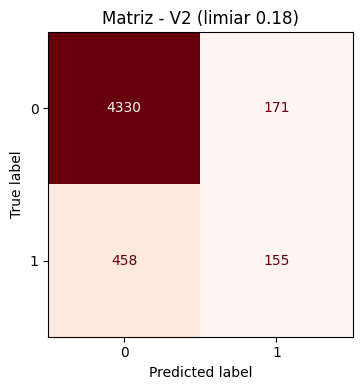

Resumo da V2:
- Limiar adotado: 0.18
- Precision atraso: 0.4755
- Recall atraso: 0.2529
- F2 atraso: 0.2790
- ROC-AUC atraso: 0.7387


In [11]:
# Celula 5: treino final com os melhores parametros + comparacao de resultados no teste.
sample_weight_v2 = np.where(y_train.values == 0, w0, 1.0)

model_v2 = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=4242,
    n_jobs=-1,
    **best_params_v2,
 )
model_v2.fit(X_train, y_train, sample_weight=sample_weight_v2)

# Converte saida do modelo para probabilidade de atraso (classe 0).
y_proba_class1_v2_train = model_v2.predict_proba(X_train)[:, 1]
y_proba_class1_v2_test = model_v2.predict_proba(X_test)[:, 1]
y_proba_atraso_v2_train = 1.0 - y_proba_class1_v2_train
y_proba_atraso_v2_test = 1.0 - y_proba_class1_v2_test

# Mantem o limiar escolhido para atraso e converte a decisao equivalente para a classe 1.
threshold_class1_v2 = 1.0 - best_threshold_v2
y_pred_class1_v2_train = (y_proba_class1_v2_train >= threshold_class1_v2).astype(int)
y_pred_class1_v2_test = (y_proba_class1_v2_test >= threshold_class1_v2).astype(int)
y_pred_atraso_v2 = (y_proba_atraso_v2_test >= best_threshold_v2).astype(int)

res_v2 = metricas_atraso(y_test, y_pred_atraso_v2, y_proba_atraso_v2_test)
metricas_treino_v2 = metricas_gerais(y_train, y_pred_class1_v2_train, y_proba_class1_v2_train)
metricas_teste_v2 = metricas_gerais(y_test, y_pred_class1_v2_test, y_proba_class1_v2_test)

# Recalcula a versao V2 base para comparacao justa no mesmo split de teste.
model_v1 = XGBClassifier(
    n_estimators=700,
    max_depth=6,
    learning_rate=0.04,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
 )
model_v1.fit(X_train, y_train, sample_weight=np.where(y_train.values == 0, w0, 1.0))
y_proba_atraso_v1 = 1.0 - model_v1.predict_proba(X_test)[:, 1]
y_pred_atraso_v1 = (y_proba_atraso_v1 >= 0.50).astype(int)
res_v1 = metricas_atraso(y_test, y_pred_atraso_v1, y_proba_atraso_v1)

df_comp_v2 = pd.DataFrame([res_v1, res_v2], index=["V2 atual", "V2"])
print("Comparacao no teste (foco em atraso):")
display(df_comp_v2.round(4))

# Explicacao breve das metricas para leitura dos resultados.
print("\nComo interpretar as metricas:")
print("- precision_atraso: entre os pedidos previstos como atraso, quantos realmente atrasaram.")
print("- recall_atraso: entre os pedidos que realmente atrasaram, quantos o modelo conseguiu detectar.")
print("- f1_atraso: media harmonica entre precision e recall (equilibrio entre os dois).")
print("- f2_atraso: semelhante ao F1, mas dando mais peso ao recall (bom para nao perder atrasos).")
print("- roc_auc_atraso: capacidade de separar atraso vs nao atraso em todos os limiares (quanto maior, melhor).")
print("- pr_auc_atraso: qualidade do modelo no trade-off precision x recall para classe rara (atraso).")

# Exibe matriz de confusao para visualizar erros da V2.
y_true_atraso_test = (y_test == 0).astype(int)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_true_atraso_test, y_pred_atraso_v2, cmap="Reds", ax=ax, colorbar=False
 )
ax.set_title(f"Matriz - V2 (limiar {best_threshold_v2:.2f})")
plt.tight_layout()
plt.show()

print("Resumo da V2:")
print(f"- Limiar adotado: {best_threshold_v2:.2f}")
print(f"- Precision atraso: {res_v2['precision_atraso']:.4f}")
print(f"- Recall atraso: {res_v2['recall_atraso']:.4f}")
print(f"- F2 atraso: {res_v2['f2_atraso']:.4f}")
print(f"- ROC-AUC atraso: {res_v2['roc_auc_atraso']:.4f}")

In [12]:
# Celula 6: resumo completo com metricas gerais e metricas de atraso para V1 e V2
print("=" * 120)
print("RESUMO COMPLETO DAS METRICAS DO XGBOOST")
print("=" * 120)

# Calcula metricas para V1 no treino e teste
y_proba_atraso_v1_train = 1.0 - model_v1.predict_proba(X_train)[:, 1]
y_pred_atraso_v1_train = (y_proba_atraso_v1_train >= 0.50).astype(int)
res_v1_train = metricas_atraso(y_train, y_pred_atraso_v1_train, y_proba_atraso_v1_train)

# Calcula métricas gerais para V1 no treino e teste
metricas_treino_v1 = metricas_gerais(y_train, model_v1.predict(X_train), model_v1.predict_proba(X_train)[:, 1])
metricas_teste_v1 = metricas_gerais(y_test, model_v1.predict(X_test), model_v1.predict_proba(X_test)[:, 1])

# Calcula metricas para V2 no treino (ja temos do teste)
y_pred_atraso_v2_train = (y_proba_atraso_v2_train >= best_threshold_v2).astype(int)
res_v2_train = metricas_atraso(y_train, y_pred_atraso_v2_train, y_proba_atraso_v2_train)

# ============================================================================
# METRICAS GERAIS
# ============================================================================
print("\nMETRICAS GERAIS")
print("(Accuracy, Precision, Recall, F1-score, ROC-AUC, PR-AUC, Balanced Accuracy, MCC, Brier Score, Log Loss)")

print("\n" + "─" * 120)
print("V1 - TREINO")
print("─" * 120)
df_v1_train_geral = pd.DataFrame(pd.Series(metricas_treino_v1, name="V1 Treino"))
display(df_v1_train_geral.round(4))

print("\n" + "─" * 120)
print("V1 - TESTE")
print("─" * 120)
df_v1_test_geral = pd.DataFrame(pd.Series(metricas_teste_v1, name="V1 Teste"))
display(df_v1_test_geral.round(4))

print("\n" + "─" * 120)
print("V2 - TREINO")
print("─" * 120)
df_v2_train_geral = pd.DataFrame(pd.Series(metricas_treino_v2, name="V2 Treino"))
display(df_v2_train_geral.round(4))

print("\n" + "─" * 120)
print("V2 - TESTE")
print("─" * 120)
df_v2_test_geral = pd.DataFrame(pd.Series(metricas_teste_v2, name="V2 Teste"))
display(df_v2_test_geral.round(4))

# Comparacao lado a lado - Metricas Gerais
print("\n" + "─" * 120)
print("COMPARACAO: V1 vs V2 - TREINO (Metricas Gerais)")
print("─" * 120)
df_comp_treino_geral = pd.DataFrame({
    "V1 Treino": metricas_treino_v1,
    "V2 Treino": metricas_treino_v2,
})
display(df_comp_treino_geral.round(4))

print("\n" + "─" * 120)
print("COMPARACAO: V1 vs V2 - TESTE (Metricas Gerais)")
print("─" * 120)
df_comp_teste_geral = pd.DataFrame({
    "V1 Teste": metricas_teste_v1,
    "V2 Teste": metricas_teste_v2,
})
display(df_comp_teste_geral.round(4))

# ============================================================================
# METRICAS DE ATRASO (CLASSE 0)
# ============================================================================
print("METRICAS DE ATRASO (CLASSE 0)")
print("(Accuracy, Precision, Recall, F1, F2, ROC-AUC, PR-AUC, Balanced Accuracy, MCC, Brier Score, Log Loss)")

print("\n" + "─" * 120)
print("V1 - TREINO (ATRASO)")
print("─" * 120)
df_v1_train_atraso = pd.DataFrame(pd.Series(res_v1_train, name="V1 Treino"))
display(df_v1_train_atraso.round(4))

print("\n" + "─" * 120)
print("V1 - TESTE (ATRASO)")
print("─" * 120)
df_v1_test_atraso = pd.DataFrame(pd.Series(res_v1, name="V1 Teste"))
display(df_v1_test_atraso.round(4))

print("\n" + "─" * 120)
print("V2 - TREINO (ATRASO)")
print("─" * 120)
df_v2_train_atraso = pd.DataFrame(pd.Series(res_v2_train, name="V2 Treino"))
display(df_v2_train_atraso.round(4))

print("\n" + "─" * 120)
print("V2 - TESTE (ATRASO)")
print("─" * 120)
df_v2_test_atraso = pd.DataFrame(pd.Series(res_v2, name="V2 Teste"))
display(df_v2_test_atraso.round(4))

# Comparacao lado a lado - Metricas de Atraso
print("\n" + "─" * 120)
print("COMPARACAO: V1 vs V2 - TREINO (Atraso)")
print("─" * 120)
df_comp_treino_atraso = pd.DataFrame({
    "V1 Treino": res_v1_train,
    "V2 Treino": res_v2_train,
})
display(df_comp_treino_atraso.round(4))

print("\n" + "─" * 120)
print("COMPARACAO: V1 vs V2 - TESTE (Atraso)")
print("─" * 120)
df_comp_teste_atraso = pd.DataFrame({
    "V1 Teste": res_v1,
    "V2 Teste": res_v2,
})
display(df_comp_teste_atraso.round(4))

# ============================================================================
# RESUMO
# ============================================================================
print("RESUMO")

print(f"\n\n{'V1 (Baseline)':-^120}")
print(f"  Limiar utilizado: 0.50")
print(f"  Treino - Accuracy: {metricas_treino_v1['Accuracy']:.4f}, ROC-AUC: {metricas_treino_v1['ROC-AUC']:.4f}, "
      f"Precision (Atraso): {res_v1_train['precision_atraso']:.4f}, Recall (Atraso): {res_v1_train['recall_atraso']:.4f}")
print(f"  Teste  - Accuracy: {metricas_teste_v1['Accuracy']:.4f}, ROC-AUC: {metricas_teste_v1['ROC-AUC']:.4f}, "
      f"Precision (Atraso): {res_v1['precision_atraso']:.4f}, Recall (Atraso): {res_v1['recall_atraso']:.4f}")

print(f"\n{'V2 (Otimizado)':-^120}")
print(f"  Limiar utilizado: {best_threshold_v2:.2f}")
print(f"  Treino - Accuracy: {metricas_treino_v2['Accuracy']:.4f}, ROC-AUC: {metricas_treino_v2['ROC-AUC']:.4f}, "
      f"Precision (Atraso): {res_v2_train['precision_atraso']:.4f}, Recall (Atraso): {res_v2_train['recall_atraso']:.4f}")
print(f"  Teste  - Accuracy: {metricas_teste_v2['Accuracy']:.4f}, ROC-AUC: {metricas_teste_v2['ROC-AUC']:.4f}, "
      f"Precision (Atraso): {res_v2['precision_atraso']:.4f}, Recall (Atraso): {res_v2['recall_atraso']:.4f}")

print(f"\n{'Melhoria no Teste (V2 vs V1)':-^120}")
print(f"  Metricas Gerais:")
print(f"    - Accuracy: {((metricas_teste_v2['Accuracy'] - metricas_teste_v1['Accuracy']) / metricas_teste_v1['Accuracy'] * 100):+.2f}%")
print(f"    - ROC-AUC: {((metricas_teste_v2['ROC-AUC'] - metricas_teste_v1['ROC-AUC']) / metricas_teste_v1['ROC-AUC'] * 100):+.2f}%")
print(f"  Metricas de Atraso:")
if res_v2['precision_atraso'] != 0:
    print(f"    - Precision (Atraso): {((res_v2['precision_atraso'] - res_v1['precision_atraso']) / res_v1['precision_atraso'] * 100):+.2f}%")
if res_v2['recall_atraso'] != 0:
    print(f"    - Recall (Atraso): {((res_v2['recall_atraso'] - res_v1['recall_atraso']) / res_v1['recall_atraso'] * 100):+.2f}%")
if res_v2['f2_atraso'] != 0:
    print(f"    - F2 (Atraso): {((res_v2['f2_atraso'] - res_v1['f2_atraso']) / res_v1['f2_atraso'] * 100):+.2f}%")
if res_v2['roc_auc_atraso'] != 0:
    print(f"    - ROC-AUC (Atraso): {((res_v2['roc_auc_atraso'] - res_v1['roc_auc_atraso']) / res_v1['roc_auc_atraso'] * 100):+.2f}%")


RESUMO COMPLETO DAS METRICAS DO XGBOOST

METRICAS GERAIS
(Accuracy, Precision, Recall, F1-score, ROC-AUC, PR-AUC, Balanced Accuracy, MCC, Brier Score, Log Loss)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
V1 - TREINO
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


,V1 Treino
Accuracy,0.9829
Precision,1.0000
Recall,0.9820
F1-score,0.9909
ROC-AUC,0.9995
PR-AUC,1.0000
Balanced Accuracy,0.9910
MCC,0.8544
Brier Score,0.0246
Log Loss,0.1201



────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
V1 - TESTE
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


,V1 Teste
Accuracy,0.8850
Precision,0.8944
Recall,0.9858
F1-score,0.9379
ROC-AUC,0.7437
PR-AUC,0.9448
Balanced Accuracy,0.5655
MCC,0.2497
Brier Score,0.0942
Log Loss,0.3473



────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
V2 - TREINO
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


...


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
COMPARACAO: V1 vs V2 - TREINO (Atraso)
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


,V1 Treino,V2 Treino
accuracy_atraso,0.9829,0.9309
precision_atraso,0.7433,0.4180
recall_atraso,1.0000,1.0000
f1_atraso,0.8528,0.5896
f2_atraso,0.9354,0.7822
roc_auc_atraso,0.9995,1.0000
pr_auc_atraso,0.9903,0.9998
balanced_accuracy_atraso,0.9910,0.9636
mcc_atraso,0.8544,0.6226
brier_score_atraso,0.0246,0.0099



────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
COMPARACAO: V1 vs V2 - TESTE (Atraso)
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


,V1 Teste,V2 Teste
accuracy_atraso,0.8850,0.8770
precision_atraso,0.5817,0.4755
recall_atraso,0.1452,0.2529
f1_atraso,0.2324,0.3301
f2_atraso,0.1708,0.2790
roc_auc_atraso,0.7437,0.7387
pr_auc_atraso,0.3589,0.3600
balanced_accuracy_atraso,0.5655,0.6074
mcc_atraso,0.2497,0.2857
brier_score_atraso,0.0942,0.0968


RESUMO


-----------------------------------------------------V1 (Baseline)------------------------------------------------------
  Limiar utilizado: 0.50
  Treino - Accuracy: 0.9829, ROC-AUC: 0.9995, Precision (Atraso): 0.7433, Recall (Atraso): 1.0000
  Teste  - Accuracy: 0.8850, ROC-AUC: 0.7437, Precision (Atraso): 0.5817, Recall (Atraso): 0.1452

-----------------------------------------------------V2 (Otimizado)-----------------------------------------------------
  Limiar utilizado: 0.18
  Treino - Accuracy: 0.9309, ROC-AUC: 1.0000, Precision (Atraso): 0.4180, Recall (Atraso): 1.0000
  Teste  - Accuracy: 0.8770, ROC-AUC: 0.7387, Precision (Atraso): 0.4755, Recall (Atraso): 0.2529

----------------------------------------------Melhoria no Teste (V2 vs V1)----------------------------------------------
  Metricas Gerais:
    - Accuracy: -0.91%
    - ROC-AUC: -0.66%
  Metricas de Atraso:
    - Precision (Atraso): -18.26%
    - Recall (Atraso): +74.16%
    - F2 (Atraso): +63.31%
    - 